In [1]:
# Notebook: scatter 3D do Iris — figura estática (matplotlib) e versão interativa (plotly).
import matplotlib.pyplot as plt
# Garante que add_subplot(..., projection="3d") funcione (registra o eixo 3D).
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
# Gráficos interativos (WebGL); exige nbformat recente no Jupyter para renderizar a saída.
import plotly.express as px

In [2]:
# CSV local (mesma pasta do notebook): 4 atributos + coluna "target" (espécie).
df = pd.read_csv("iris_dataset.csv")
# Mapa espécie → cor, reutilizado na célula do matplotlib e na do plotly.
colors = {"setosa": "red", "versicolor": "green", "virginica": "blue"}

# Pré-visualização das primeiras linhas e nomes das colunas.
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


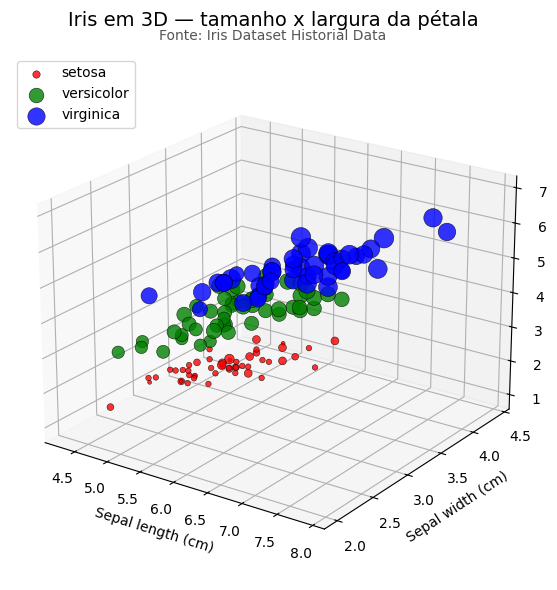

In [7]:
# Figura e um único eixo 3D (111 = 1 linha, 1 coluna, 1º subplot).
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="3d")

# Uma série de pontos por espécie (mesma cor dentro do grupo).
for species, group in df.groupby("target"):
    pw = group["petal width (cm)"]
    # scatter 3D só aceita (x, y, z); o 4º argumento posicional seria zdir, não uma coordenada.
    # A largura da pétala então codificamos no tamanho do marcador (escala empírica para leitura).
    ax.scatter(
        group["sepal length (cm)"],
        group["sepal width (cm)"],
        group["petal length (cm)"],
        s=(pw * 80).to_numpy(),
        label=species,
        color=colors[species],
        alpha=0.8,
        edgecolor="black",
        linewidths=0.4,
    )

ax.set_title("Iris em 3D — tamanho x largura da pétala", fontsize=14, pad=20)
# Texto no plano 2D da figura (coordenadas normalizadas 0–1 do eixo).
ax.text2D(
    0.5,
    1.02,
    "Fonte: Iris Dataset Historial Data",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

ax.set_xlabel("Sepal length (cm)")
ax.set_ylabel("Sepal width (cm)")
ax.set_zlabel("Petal length (cm)")

# Ângulo inicial da câmera: elevação e azimute em graus.
ax.view_init(elev=22, azim=-55)
ax.legend(loc="upper left")

plt.tight_layout()
# Alta resolução para arquivo; para só olhar no notebook, dpi menor (ex.: 150) acelera.
plt.savefig("scatter3d_iris.png", dpi=1000)
plt.show()

In [4]:
# Mesmos dados do matplotlib; renderização WebGL (arrastar para girar, zoom com scroll).
# Dependências: pip install plotly  (e nbformat>=4.2 no ambiente do Jupyter).
fig_plotly = px.scatter_3d(
    df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    z="petal length (cm)",
    color="target",
    color_discrete_map=colors,
    # Variável extra aparece no tooltip ao passar o mouse.
    hover_data={"petal width (cm)": ":.2f"},
    title="Iris em 3D — sépala e comprimento da pétala (largura da pétala no hover)",
)

# Estilo dos pontos: tamanho fixo, leve contorno (equivalente ao matplotlib).
fig_plotly.update_traces(
    marker=dict(size=6, opacity=0.85, line=dict(width=0.4, color="black"))
)
# scene: rótulos dos eixos 3D; camera.eye aproxima a visão inicial do view_init acima.
fig_plotly.update_layout(
    scene=dict(
        xaxis_title="Sepal length (cm)",
        yaxis_title="Sepal width (cm)",
        zaxis_title="Petal length (cm)",
        camera=dict(eye=dict(x=1.35, y=-1.35, z=0.55)),
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    annotations=[
        dict(
            text="Fonte: Iris Dataset Historial Data",
            xref="paper",
            yref="paper",
            x=0.5,
            y=1.06,
            showarrow=False,
            font=dict(size=10, color="#555555"),
        )
    ],
    legend_title_text="Espécie",
)
fig_plotly.show()